GP_Model_Tuning - 5/4/2026 - derave1577

In [1]:
# Import necessary libraries
import os
os.environ["KERAS_BACKEND"] = "torch"
import torch
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "derave1577"
# Load the LFW dataset
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
data = lfw_people.data
target = lfw_people.target
target_names = lfw_people.target_names
# Display dataset information
display(Markdown("### Step 1.2: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
print(f"Data shape: {data.shape}")
print(f"Number of classes: {len(target_names)}")
print(f"Classes: {target_names}")

### Step 1.2: Load the Dataset

Date: 2026-05-04

Student ID: derave1577

Data shape: (1288, 1850)
Number of classes: 7
Classes: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


### Step 1.3: Initial Exploration of the Dataset

Date: 2026-05-04

Student ID: derave1577

First few rows of the data:
[[0.9973857  0.99607843 0.9921568  ... 0.38169935 0.38823533 0.3803922 ]
 [0.14771242 0.19738562 0.1751634  ... 0.45751634 0.44444445 0.53594774]
 [0.34379086 0.39477125 0.49150327 ... 0.709804   0.72156864 0.7163399 ]
 [0.04705882 0.01699346 0.02352941 ... 0.06535948 0.14248367 0.20130719]
 [0.47189546 0.45882353 0.4862745  ... 0.07843138 0.2509804  0.2784314 ]]
Target values:
[5 6 3 1 0]


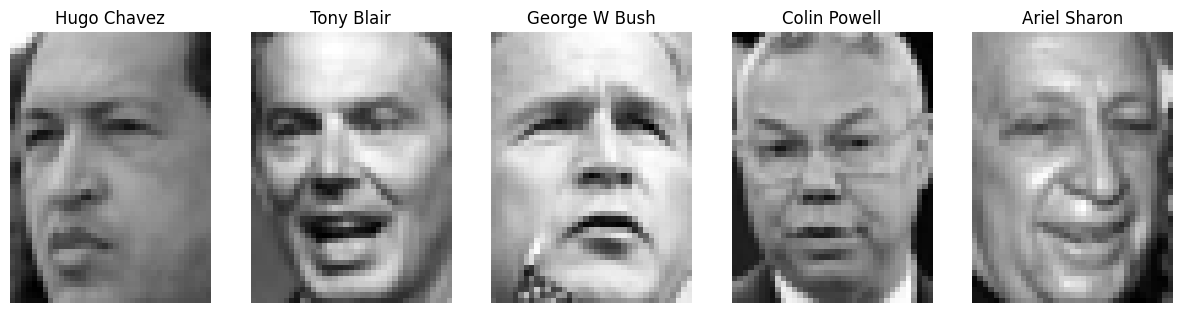

In [2]:
display(Markdown("### Step 1.3: Initial Exploration of the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Display the first few rows of the data
print("First few rows of the data:")
print(data[:5])
# Display the target values
print("Target values:")
print(target[:5])
# Display the first few sample images with their target values
fig, axes = plt.subplots(1, 5, figsize=(15, 6))
for i in range(5):
    axes[i].imshow(data[i].reshape(50, 37), cmap='gray')
    axes[i].set_title(target_names[target[i]])
    axes[i].axis('off')
plt.show()

In [5]:
display(Markdown("### Step 1.4: Manual Feature Engineering"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Normalize the pixel values
data = data / 255.0
# Add additional features if needed (e.g., pixel intensity statistics)
mean_pixel_values = np.mean(data, axis=1).reshape(-1, 1)
std_pixel_values = np.std(data, axis=1).reshape(-1, 1)
# Concatenate the new features with the original data
data_with_features = np.hstack((data, mean_pixel_values, std_pixel_values))
print(f"New data shape with engineered features: {data_with_features.shape}")

### Step 1.4: Manual Feature Engineering

Date: 2026-05-04

Student ID: derave1577

New data shape with engineered features: (1288, 1852)


In [6]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
display(Markdown("### Step 2.1: Building the TensorFlow Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data_with_features, target, test_size=0.2, random_state=42)
# Convert the target to categorical
y_train_cat = keras.utils.to_categorical(y_train, len(target_names))
y_test_cat = keras.utils.to_categorical(y_test, len(target_names))
# Build the neural network model
model = Sequential([
    Dense(256, activation='relu', input_shape=(data_with_features.shape[1],)), Dropout(0.5),
    Dense(128, activation='relu'), Dropout(0.5),
    Dense(len(target_names), activation='softmax')
])
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
# Display the model summary
model.summary()

### Step 2.1: Building the TensorFlow Model

Date: 2026-05-04

Student ID: derave1577

C:\Users\Derek A\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         474,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 508,167 (1.94 MB)

 Trainable params: 508,167 (1.94 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
display(Markdown("### Step 2.2: Training the TensorFlow Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)
# Save the model
model.save('face_recognition_model.keras')

### Step 2.2: Training the TensorFlow Model

Date: 2026-05-04

Student ID: derave1577

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6549 - sparse_categorical_accuracy: 0.3981 - val_loss: 1.6172 - val_sparse_categorical_accuracy: 0.4029
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6403 - sparse_categorical_accuracy: 0.3981 - val_loss: 1.5977 - val_sparse_categorical_accuracy: 0.4029
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6221 - sparse_categorical_accuracy: 0.4017 - val_loss: 1.5909 - val_sparse_categorical_accuracy: 0.4029
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6105 - sparse_categorical_accuracy: 0.4041 - val_loss: 1.5717 - val_sparse_categorical_accuracy: 0.4078
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5856 - sparse_categorical_accuracy: 0.4138 - val_loss: 1.5683 - val_sparse_categorical_accuracy: 0.4175
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5838 - sparse_categorical_accuracy: 0.4272 - val_loss: 1.5492 - val_sparse_categorical_accuracy: 0.4466
Epoch 7/20
26/26

### Step 2.3: Visualizing Model Performance

Date: 2026-05-04

Student ID: derave1577

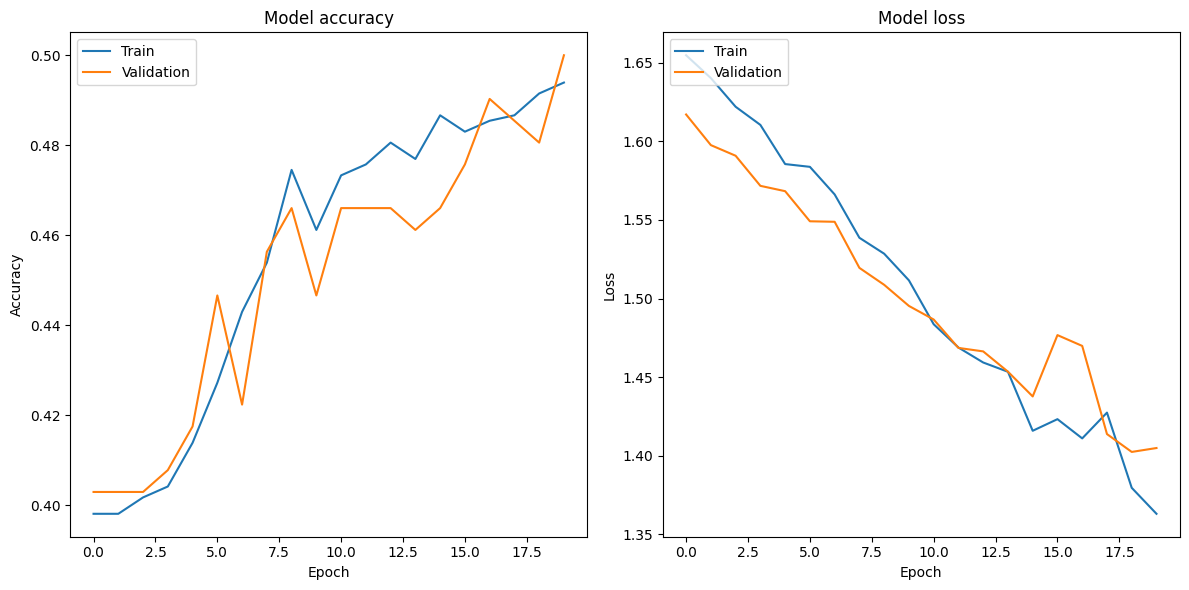

In [10]:
display(Markdown("### Step 2.3: Visualizing Model Performance"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
display(Markdown("### Step 3.1: Advanced Feature Engineering"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Perform PCA for dimensionality reduction
pca = PCA(n_components=150, whiten=True, random_state=42)
data_pca = pca.fit_transform(data)
# Add additional features if needed (e.g., pixel intensity statistics)
mean_pixel_values = np.mean(data_pca, axis=1).reshape(-1, 1)
std_pixel_values = np.std(data_pca, axis=1).reshape(-1, 1)
# Concatenate the new features with the PCA data
data_with_features = np.hstack((data_pca, mean_pixel_values, std_pixel_values))
print(f"New data shape with engineered features: {data_with_features.shape}")

### Step 3.1: Advanced Feature Engineering

Date: 2026-05-04

Student ID: derave1577

New data shape with engineered features: (1288, 152)


In [15]:
display(Markdown("### Step 3.2: Train the Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data_with_features, target, test_size=0.2, random_state=42)
# Convert the target to categorical
y_train_cat = keras.utils.to_categorical(y_train, len(target_names))
y_test_cat = keras.utils.to_categorical(y_test, len(target_names))
# Build the neural network model
model = Sequential([
    Dense(256, activation='relu', input_shape=(data_with_features.shape[1],)), 
    Dropout(0.5),
    Dense(128, activation='relu'), 
    Dropout(0.5),
    Dense(len(target_names), activation='softmax')
])
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
# Display the model summary
model.summary()
# Train the model
PCA_history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)
# Save the model
model.save('face_recognition_model_with_features.keras')

### Step 3.2: Train the Model

Date: 2026-05-04

Student ID: derave1577

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 256)                 │          39,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 72,967 (285.03 KB)

 Trainable params: 72,967 (285.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0675 - sparse_categorical_accuracy: 0.3010 - val_loss: 1.5982 - val_sparse_categorical_accuracy: 0.4417
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7420 - sparse_categorical_accuracy: 0.3920 - val_loss: 1.5106 - val_sparse_categorical_accuracy: 0.4709
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5532 - sparse_categorical_accuracy: 0.4575 - val_loss: 1.4346 - val_sparse_categorical_accuracy: 0.5146
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.4066 - sparse_categorical_accuracy: 0.5036 - val_loss: 1.3177 - val_sparse_categorical_accuracy: 0.5631
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2131 - sparse_categorical_accuracy: 0.5777 - val_loss: 1.1948 - val_sparse_categorical_accuracy: 0.6019
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0943 - sparse_categorical_accuracy: 0.6080 - val_loss: 1.0511 - val_sparse_categorical_accuracy: 0.7233
Epoch 7/20
26/26

### Step 3.3: Visualizing Model Performance

Date: 2026-05-04

Student ID: derave1577

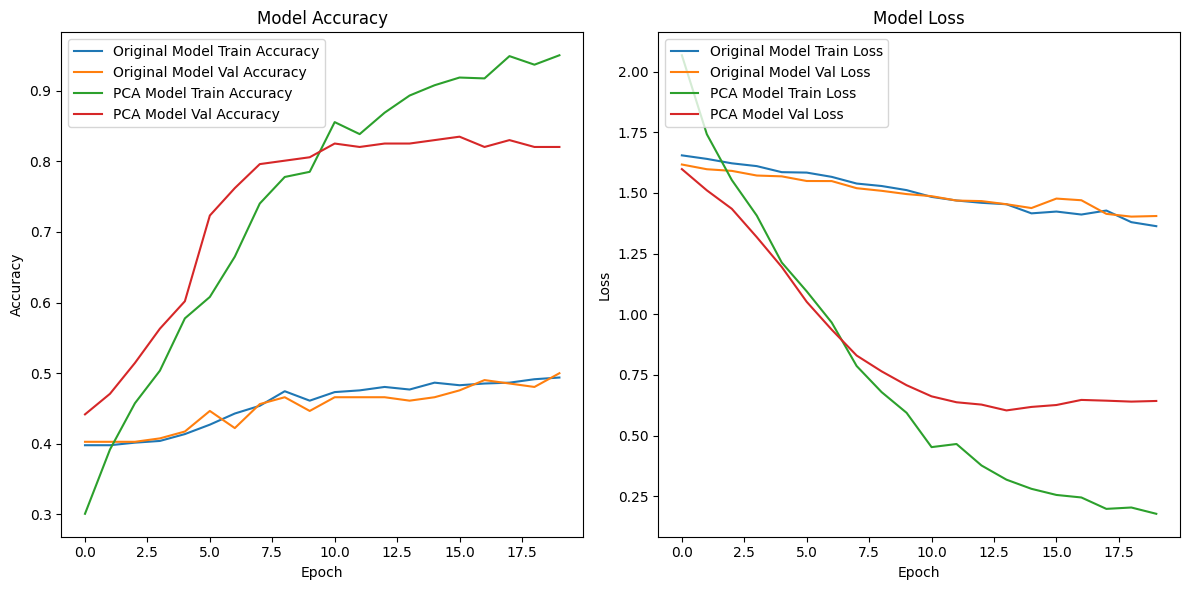

In [16]:
display(Markdown("### Step 3.3: Visualizing Model Performance"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Plot training & validation accuracy values for both old and new models
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['sparse_categorical_accuracy'], label='Original Model Train Accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='Original Model Val Accuracy')
plt.plot(PCA_history.history['sparse_categorical_accuracy'], label='PCA Model Train Accuracy')
plt.plot(PCA_history.history['val_sparse_categorical_accuracy'], label='PCA Model Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
# Plot training & validation loss values for both old and new models
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Original Model Train Loss')
plt.plot(history.history['val_loss'], label='Original Model Val Loss')
plt.plot(PCA_history.history['loss'], label='PCA Model Train Loss')
plt.plot(PCA_history.history['val_loss'], label='PCA Model Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [17]:
display(Markdown("### Step 3.4: Perform Hyperparameter Tuning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Define a function to create the model (required for KerasClassifier)
def create_model(optimizer='adam'):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(data_with_features.shape[1],)),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(len(target_names), activation='softmax')
    ])
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
    return model
# Create the KerasClassifier wrapper
model = KerasClassifier(model=create_model, optimizer='adam', epochs=20, batch_size=32, verbose=0)
# Define the grid search parameters
param_grid = {'optimizer': ['adam', 'rmsprop', 'sgd'], 'batch_size': [16, 32, 64], 'epochs': [5, 10, 15]}
# Initialize GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=- 1, cv=3)
grid_result = grid.fit(X_train, y_train)
# Display the best parameters and best score
print(f"Best Parameters: {grid_result.best_params_}")
print(f"Best Score: {grid_result.best_score_}")

### Step 3.4: Perform Hyperparameter Tuning

Date: 2026-05-04

Student ID: derave1577

C:\Users\Derek A\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best Parameters: {'batch_size': 16, 'epochs': 15, 'optimizer': 'rmsprop'}
Best Score: 0.8058116934481433


### Step 3.5: Applying Best Parameters and Retraining the Model

Date: 2026-05-04

Student ID: derave1577

Epoch 1/15
37/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2060 - sparse_categorical_accuracy: 0.2712

C:\Users\Derek A\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0103 - sparse_categorical_accuracy: 0.3265 - val_loss: 1.5677 - val_sparse_categorical_accuracy: 0.4223
Epoch 2/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6407 - sparse_categorical_accuracy: 0.4150 - val_loss: 1.4241 - val_sparse_categorical_accuracy: 0.4563
Epoch 3/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4113 - sparse_categorical_accuracy: 0.5000 - val_loss: 1.2665 - val_sparse_categorical_accuracy: 0.5437
Epoch 4/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1717 - sparse_categorical_accuracy: 0.5777 - val_loss: 1.0843 - val_sparse_categorical_accuracy: 0.6068
Epoch 5/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9749 - sparse_categorical_accuracy: 0.6687 - val_loss: 0.8758 - val_sparse_categorical_accuracy: 0.7670
Epoch 6/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8013 - sparse_categorical_accuracy: 0.7184 - val_loss: 0.7672 - val_sparse_categorical_accuracy: 0.7767
Epoch 7/15
52/52 ━━━━━━━━━━

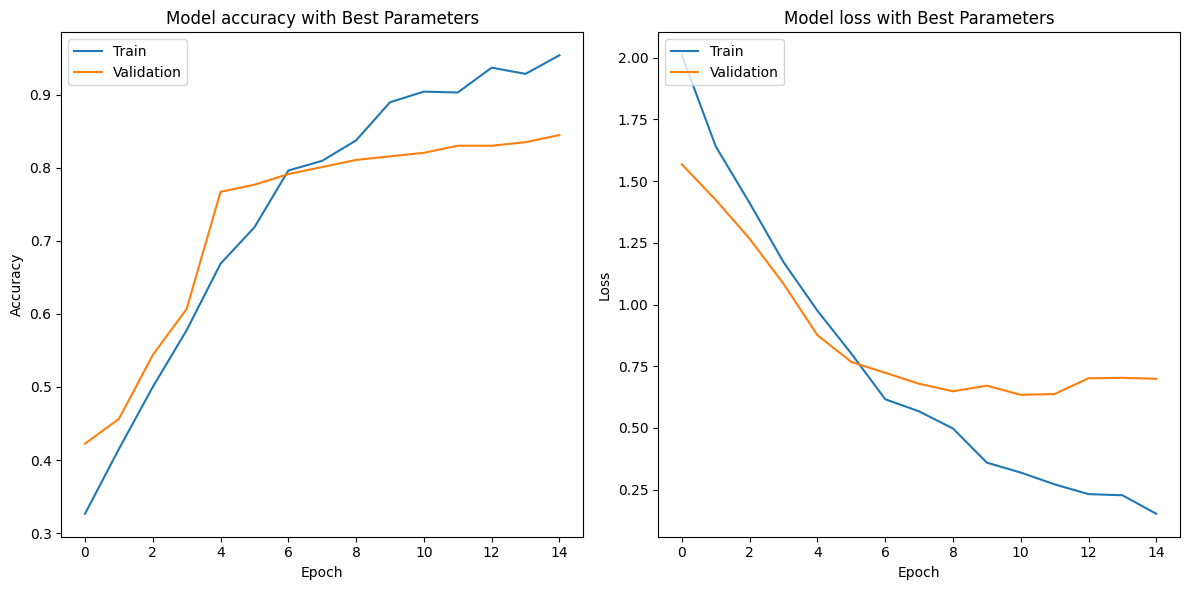

In [18]:
display(Markdown("### Step 3.5: Applying Best Parameters and Retraining the Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Apply the best parameters
best_params = grid_result.best_params_
# Retrain the model with the best parameters
best_model = create_model(optimizer=best_params['optimizer'])
HP_history = best_model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'], validation_split=0.2, verbose=1)
# Save the best model
best_model.save('best_face_recognition_model.keras')
# Evaluate the model on the test set
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc}")
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(HP_history.history['sparse_categorical_accuracy'])
plt.plot(HP_history.history['val_sparse_categorical_accuracy'])
plt.title('Model accuracy with Best Parameters')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(HP_history.history['loss'])
plt.plot(HP_history.history['val_loss'])
plt.title('Model loss with Best Parameters')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

### Step 3.6: Compare Optimized Model Performances

Date: 2026-05-04

Student ID: derave1577

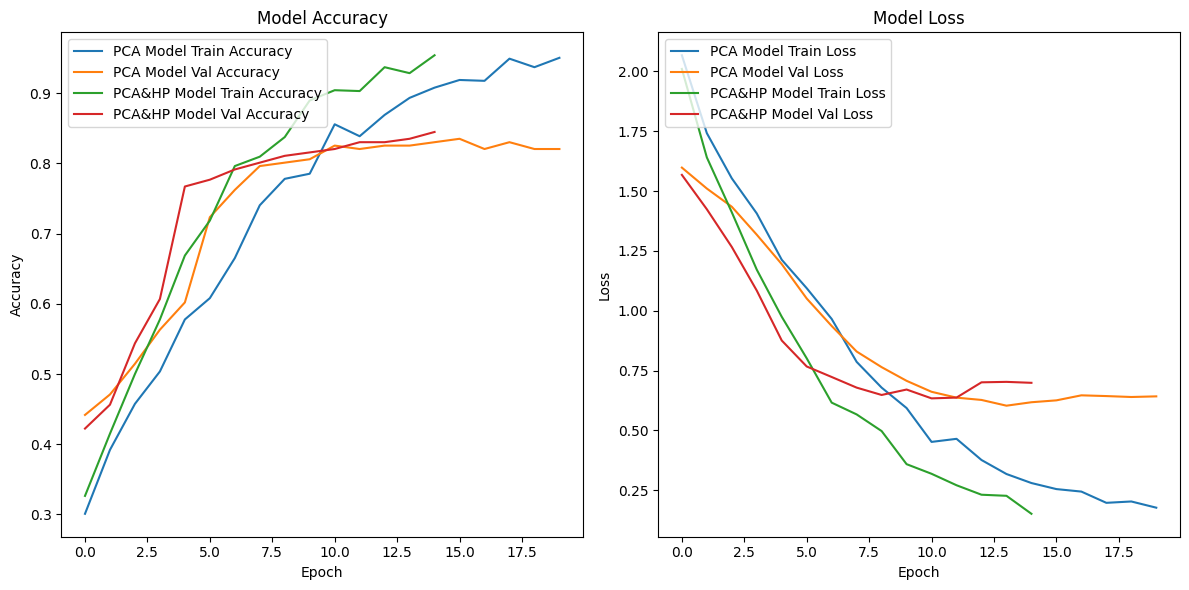

In [19]:
display(Markdown("### Step 3.6: Compare Optimized Model Performances"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Plot training & validation accuracy values for both old and new models
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(PCA_history.history['sparse_categorical_accuracy'], label='PCA Model Train Accuracy')
plt.plot(PCA_history.history['val_sparse_categorical_accuracy'], label='PCA Model Val Accuracy')
plt.plot(HP_history.history['sparse_categorical_accuracy'], label='PCA&HP Model Train Accuracy')
plt.plot(HP_history.history['val_sparse_categorical_accuracy'], label='PCA&HP Model Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
# Plot training & validation loss values for both old and new models
plt.subplot(1, 2, 2)
plt.plot(PCA_history.history['loss'], label='PCA Model Train Loss')
plt.plot(PCA_history.history['val_loss'], label='PCA Model Val Loss')
plt.plot(HP_history.history['loss'], label='PCA&HP Model Train Loss')
plt.plot(HP_history.history['val_loss'], label='PCA&HP Model Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()